In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('data/data.duckdb', read_only=True)
print('Connected. Tables:', con.execute('SHOW TABLES').df()['name'].tolist())

Connected. Tables: ['customers', 'orders']


In [ ]:
kpi = con.execute('''
    SELECT
        COUNT(*)                    AS total_orders,
        SUM(box_price_nok)          AS total_revenue_nok,
        AVG(delivered_on_time::INT) AS on_time_rate
    FROM orders
''').df()

n_customers = con.execute('SELECT COUNT(*) AS c FROM customers').df()['c'][0]

print('Customers      :', int(n_customers))
print('Orders (year)  :', int(kpi['total_orders'][0]))
print('Revenue (NOK)  :', f"{kpi['total_revenue_nok'][0]:,.0f}")
print('On-time rate   :', f"{kpi['on_time_rate'][0]*100:.1f}%")

Customers      : 2000
Orders (year)  : 16961
Revenue (NOK)  : 6,693,080
On-time rate   : 87.7%


In [11]:
by_brand = con.execute('''
    SELECT c.brand,
           COUNT(*)             AS orders,
           SUM(o.box_price_nok) AS revenue_nok
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.brand
    ORDER BY revenue_nok DESC
''').df()
by_brand

,brand,orders,revenue_nok
0,RetNemt,5793,2285261.0
1,Linas Matkasse,5553,2232584.0
2,GodtLevert,5615,2175235.0


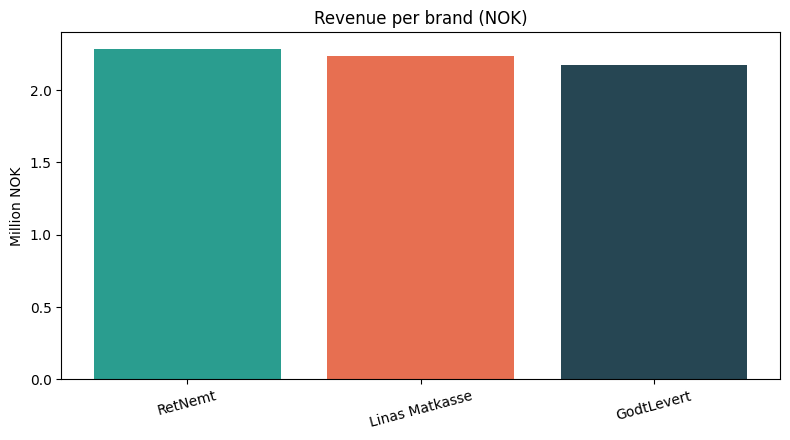

In [13]:
plt.figure(figsize=(8, 4.5))
colors = ['#2a9d8f', '#e76f51', '#264653']
plt.bar(by_brand['brand'], by_brand['revenue_nok'] / 1e6, color=colors)
plt.title('Revenue per brand (NOK)')
plt.ylabel('Million NOK')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

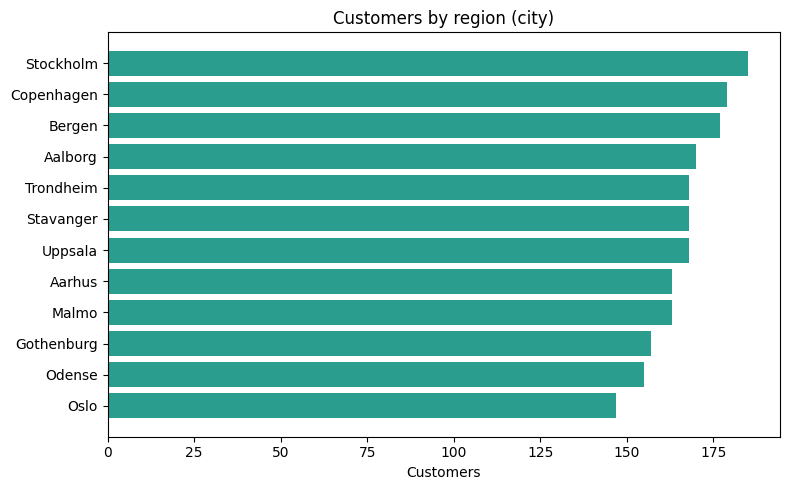

In [14]:
by_region = con.execute('''
    SELECT region, COUNT(*) AS customers
    FROM customers
    GROUP BY region
    ORDER BY customers DESC
''').df()

br = by_region.sort_values('customers')
plt.figure(figsize=(8, 5))
plt.barh(br['region'], br['customers'], color='#2a9d8f')
plt.title('Customers by region (city)')
plt.xlabel('Customers')
plt.tight_layout()
plt.show()

In [15]:
con.close()
print('Done. This is the data behind the Overview tab of the Streamlit app.')

Done. This is the data behind the Overview tab of the Streamlit app.
